# 1. 파이토치 환경확인

In [1]:
import torch
import torch.nn as nn              # 신경망 계층 (Linear, Conv2d 등)
import torch.optim as optim        # 최적화 알고리즘 (Adam, SGD 등)
from torch.utils.data import DataLoader, Dataset # 데이터 관리

In [2]:
from torchvision import datasets, models, transforms
from PIL import Image              # 이미지 파일 열기

In [4]:
import os                          # 파일 경로 관리
import numpy as np                 # 수치 계산
import matplotlib.pyplot as plt    # 이미지 및 그래프 시각화
from tqdm import tqdm              # 학습 진행률 표시 (진행바)

In [5]:
# GPU 사용 가능 여부에 따라 장치 지정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"현재 사용 가능한 장치: {device}")
if torch.cuda.is_available():
    print(f"GPU 모델명: {torch.cuda.get_device_name(0)}")

현재 사용 가능한 장치: cuda
GPU 모델명: NVIDIA GeForce RTX 4060 Laptop GPU


# 2. import 구성
이미지를 숫자로 변환하는 작업을 위해 torchvision의 datasets와 transforms 사용

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import os

# [변경] sklearn 대신 이미지 처리에 특화된 라이브러리 사용
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split # train_test_split 역할

# 3. 손상된 파일 제거

In [17]:
import os
from PIL import Image

data_dir = r'C:\Users\Admin\hipython\objdect\data\archive\PetImages'

count = 0
for root, dirs, files in os.walk(data_dir):
    for file in files:
        if file.endswith('.jpg'):
            file_path = os.path.join(root, file)
            try:
                img = Image.open(file_path)
                img.verify()  # 이미지 손상 여부 정밀 확인
            except:
                print(f"불량 파일 제거 중: {file_path}")
                # 파일이 열리지 않으면 바로 삭제합니다.
                os.remove(file_path)
                count += 1

print(f"총 {count}개의 불량 이미지를 정리했습니다. 이제 학습을 다시 시작하세요!")

총 0개의 불량 이미지를 정리했습니다. 이제 학습을 다시 시작하세요!


# 4. 데이터 로드, 전처리설정
이미지 크기를 맞추고 텐서로 변환하는 표준화 과정
TensorDataset 대신 폴더구조 인식하는 ImageFolder

In [18]:
# 1. 경로 설정 (Cat/Dog의 상위 폴더인 PetImages까지만 지정하세요)
# 문자열 앞의 'r'은 윈도우 경로의 백슬래시(\) 인식을 도와줍니다.
data_dir = r'C:\Users\Admin\hipython\objdect\data\archive\PetImages'

# 2. 전처리 설정 (Iris의 StandardScaler 역할)
# 이미지 크기를 통일하고 텐서로 변환합니다.
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),       # 모든 이미지를 224x224로 리사이즈
    transforms.ToTensor(),                # 0~255 값을 0~1 사이의 Tensor로 변환
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # 색상 정규화
])

# 3. 데이터 로딩 (load_iris() 대신 실행)
# ImageFolder는 폴더명(Cat, Dog)을 보고 자동으로 라벨(0, 1)을 붙여줍니다.
full_dataset = datasets.ImageFolder(root=data_dir, transform=data_transforms)

In [19]:
# 4. 데이터 분할 (train_test_split 역할)
# 전체 데이터 중 80%는 학습용, 20%는 검증용으로 나눕니다.
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# 5. 데이터 로더 (DataLoader 구성)
# 데이터를 32개씩 묶어서 모델에 던져줄 준비를 합니다.
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# 결과 확인
print(f"인식된 클래스: {full_dataset.classes}") # ['Cat', 'Dog']
print(f"학습 데이터 개수: {len(train_dataset)}")
print(f"검증 데이터 개수: {len(val_dataset)}")

인식된 클래스: ['Cat', 'Dog']
학습 데이터 개수: 19998
검증 데이터 개수: 5000


# 5. 모델 설계 및 손실함수 최적화

In [21]:
from torchvision import models

# 1. 사전 학습된(Pre-trained) ResNet18 모델 불러오기
# 이미 수많은 사물을 구별할 줄 아는 똑똑한 모델을 가져옵니다.
model = models.resnet18(weights='IMAGENET1K_V1')

# 2. 마지막 출력층(Fully Connected Layer) 수정
# 기본 ResNet은 1,000가지를 분류하지만, 우리는 'Cat'과 'Dog' 딱 2가지만 필요합니다.
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2) # 최종 출력을 2개(Cat, Dog)로 변경

# 3. 모델을 계산 장치(GPU 또는 CPU)로 이동
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# [5단계] 손실 함수와 최적화 알고리즘 설정
criterion = nn.CrossEntropyLoss()          # 분류 문제의 표준 손실 함수
optimizer = optim.Adam(model.parameters(), lr=0.001) # 가중치를 업데이트할 엔진

print(f"모델 준비 완료! 현재 사용 장치: {device}")

모델 준비 완료! 현재 사용 장치: cuda


# 6. 학습시작

In [22]:
model.train() # 모델을 학습 모드로 전환

for images, labels in tqdm(train_loader): # 32장씩 꺼내오기
    images, labels = images.to(device), labels.to(device) # 장치 이동
    
    # 1. 기울기 초기화
    optimizer.zero_grad()
    
    # 2. 모델 예측 (순전파)
    outputs = model(images)
    
    # 3. 오차 계산
    loss = criterion(outputs, labels)
    
    # 4. 역전파 (오차를 바탕으로 가중치 계산)
    loss.backward()
    
    # 5. 가중치 업데이트
    optimizer.step()

print("1회 학습 완료!")

100%|██████████| 625/625 [00:44<00:00, 14.04it/s]

1회 학습 완료!


# 7. 내사진으로 테스트 하기

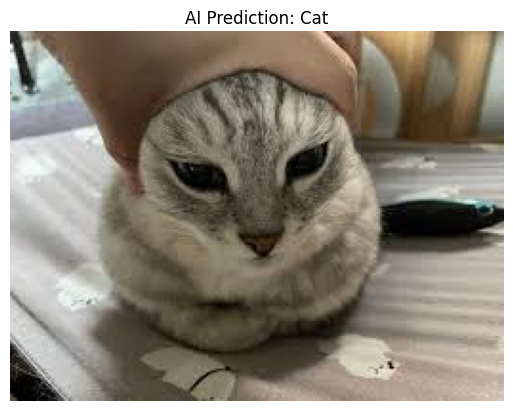

이 사진은 AI가 보기에 'Cat'일 확률이 높습니다!


In [23]:
from PIL import Image
import matplotlib.pyplot as plt

def predict_animal(image_path):
    # 1. 이미지 불러오기 및 전처리 (학습 때와 똑같은 필터 적용)
    test_transforms = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    img = Image.open(image_path).convert('RGB')
    img_tensor = test_transforms(img).unsqueeze(0).to(device) # (1, 3, 224, 224) 형태로 변환

    # 2. 모델을 예측 모드로 설정
    model.eval()
    
    with torch.no_grad():
        outputs = model(img_tensor)
        _, predicted = torch.max(outputs, 1) # 가장 확률 높은 인덱스 찾기
        
    # 3. 결과 매핑 (0: Cat, 1: Dog - ImageFolder의 기본 순서)
    classes = ['Cat', 'Dog']
    result = classes[predicted.item()]
    
    # 4. 화면 출력
    plt.imshow(img)
    plt.title(f"AI Prediction: {result}")
    plt.axis('off')
    plt.show()
    
    print(f"이 사진은 AI가 보기에 '{result}'일 확률이 높습니다!")

# [실행] 아래 경로에 본인의 테스트 이미지 경로를 넣어주세요!
# 예: r'C:\Users\Admin\Pictures\my_dog.jpg'
test_image_path = r'data/archive/cat11.jpg'
predict_animal(test_image_path)

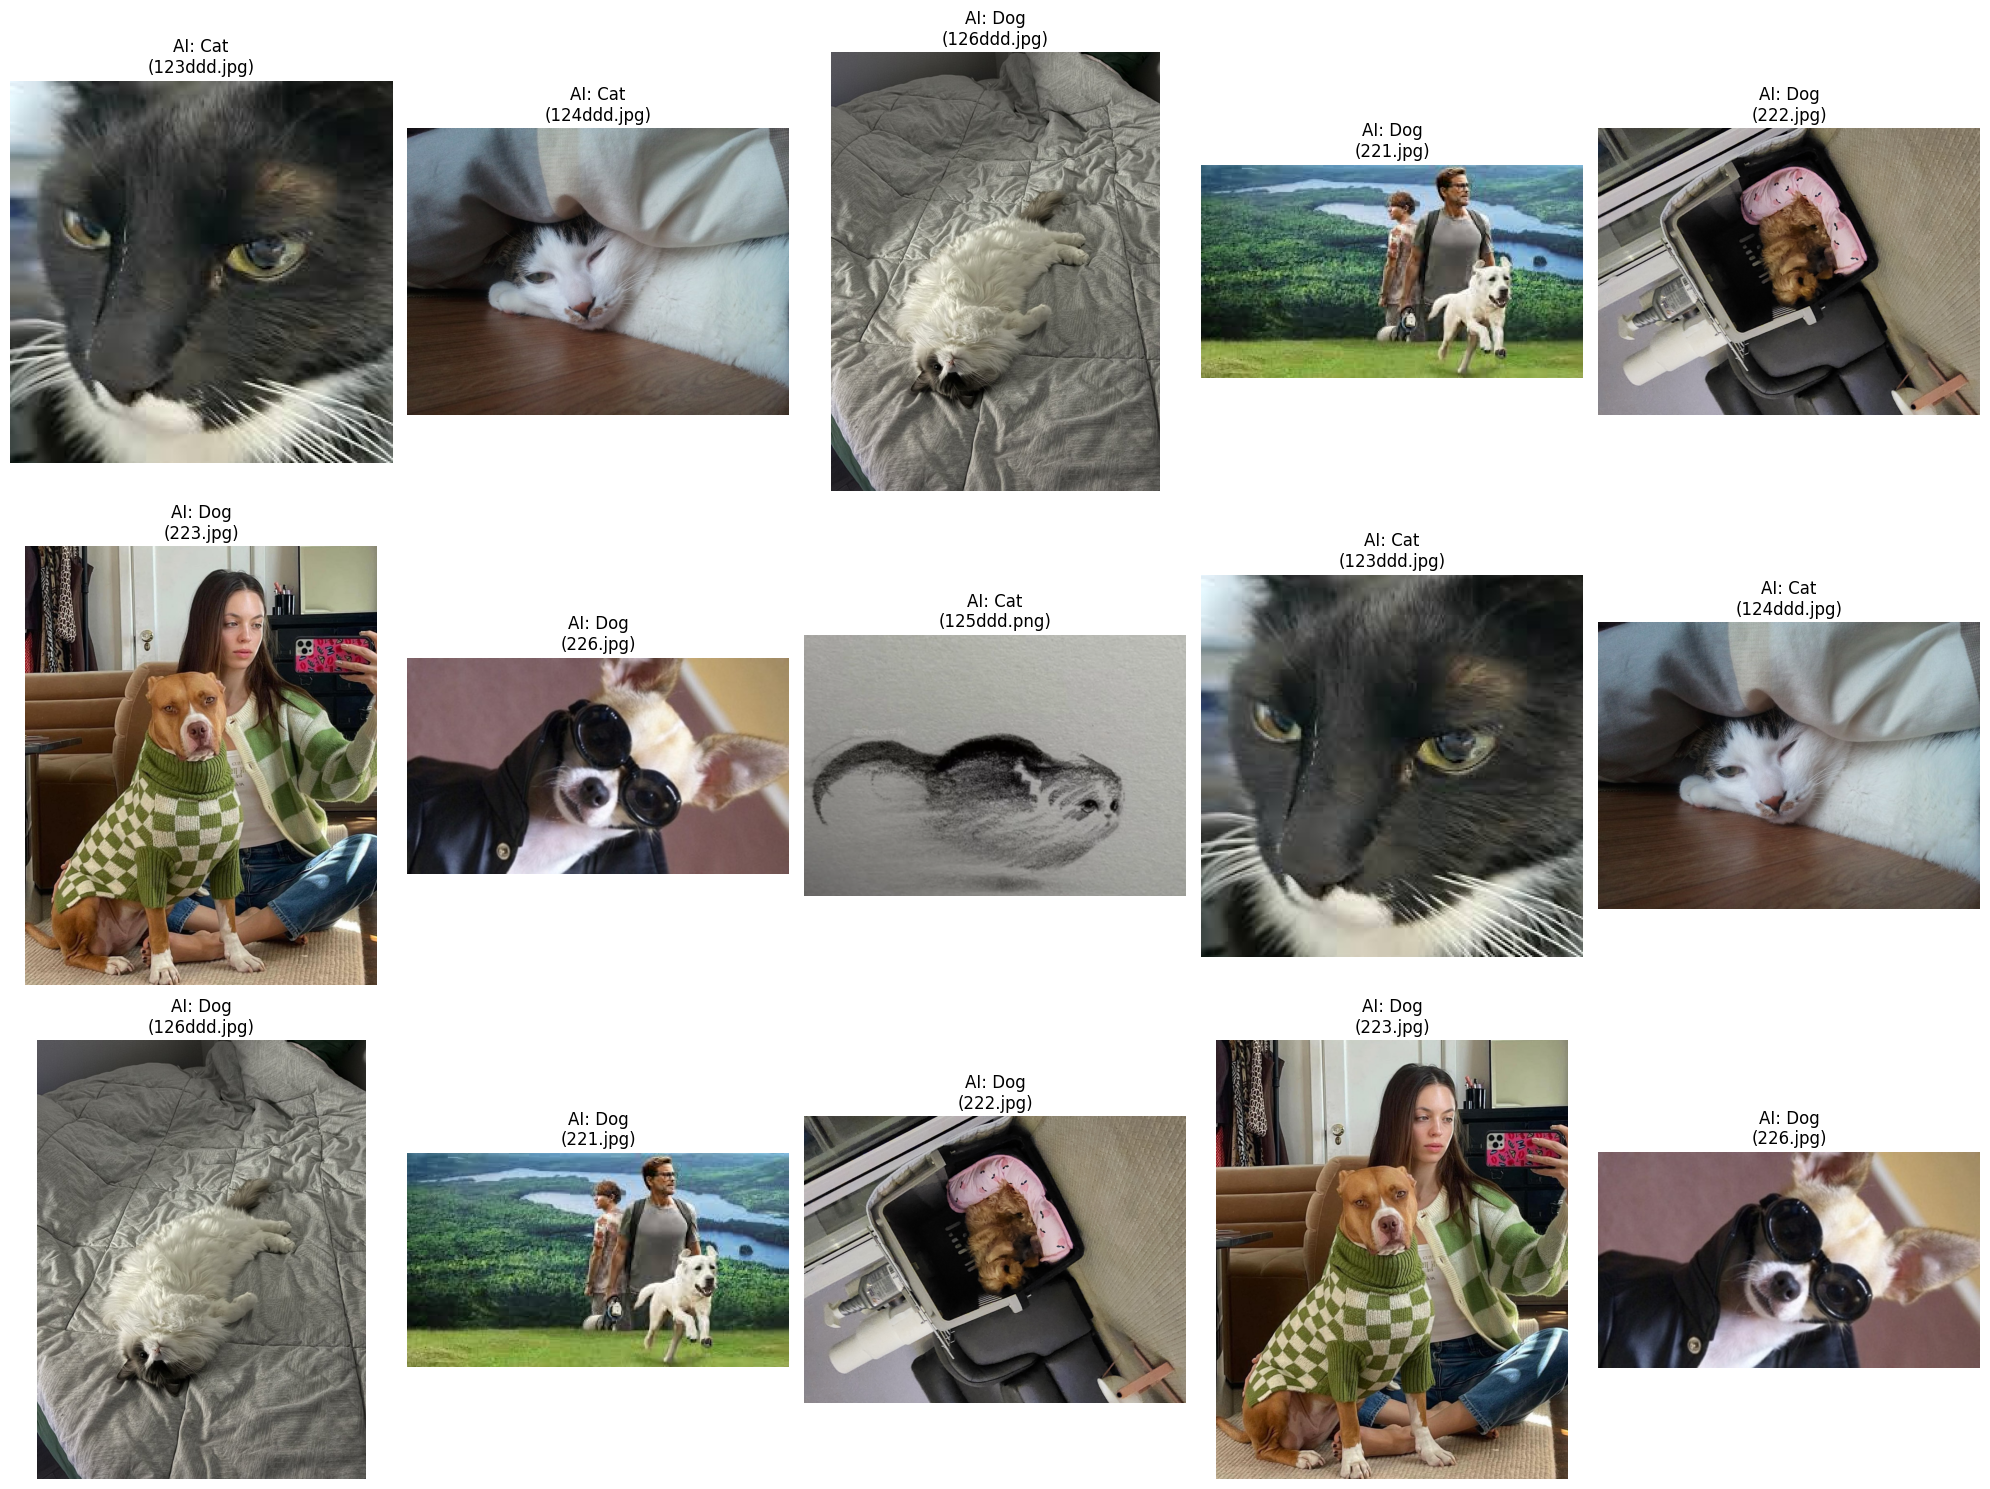

총 15장의 이미지 테스트 완료!


In [28]:
import glob
import os
from PIL import Image
import matplotlib.pyplot as plt

# 1. dtest 폴더 내의 모든 이미지 경로 가져오기
# 확장자가 대문자인 경우도 고려하여 여러 패턴을 찾습니다.
test_folder = r'data\archive\dtest'
image_extensions = ['*.jpg', '*.jpeg', '*.png', '*.JPG']
image_paths = []

for ext in image_extensions:
    image_paths.extend(glob.glob(os.path.join(test_folder, ext)))

# 2. 이미지 전처리 설정 (학습 때와 동일)
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 3. 예측 및 시각화
model.eval()
classes = ['Cat', 'Dog']

if not image_paths:
    print(f"경로를 확인해주세요. '{test_folder}' 폴더에 이미지가 없습니다.")
else:
    # 한 줄에 최대 5장씩 출력하도록 설정
    num_images = len(image_paths)
    cols = 5
    rows = (num_images // cols) + (1 if num_images % cols != 0 else 0)
    
    plt.figure(figsize=(20, 5 * rows))
    
    for i, path in enumerate(image_paths):
        try:
            # 이미지 처리
            img = Image.open(path).convert('RGB')
            img_tensor = test_transforms(img).unsqueeze(0).to(device)
            
            # 모델 예측
            with torch.no_grad():
                outputs = model(img_tensor)
                _, predicted = torch.max(outputs, 1)
                result = classes[predicted.item()]
            
            # 시각화
            plt.subplot(rows, cols, i + 1)
            plt.imshow(img)
            plt.title(f"AI: {result}\n({os.path.basename(path)})", fontsize=12)
            plt.axis('off')
            
        except Exception as e:
            print(f"오류 발생 ({path}): {e}")

    plt.tight_layout()
    plt.show()
    print(f"총 {len(image_paths)}장의 이미지 테스트 완료!")

In [29]:
import torch.nn.functional as F

def predict_with_confidence(image_paths):
    # 전처리 설정
    test_transforms = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    model.eval()
    classes = ['Cat', 'Dog']
    
    print(f"{'파일명':<20} | {'예측 결과':<10} | {'확신도 (Probability)':<20}")
    print("-" * 60)

    for path in image_paths:
        try:
            img = Image.open(path).convert('RGB')
            img_tensor = test_transforms(img).unsqueeze(0).to(device)
            
            with torch.no_grad():
                outputs = model(img_tensor)
                
                # 1. Raw 점수를 0~1 사이의 확률값으로 변환 (Softmax)
                probabilities = F.softmax(outputs, dim=1)
                
                # 2. 가장 높은 확률과 해당 인덱스 추출
                prob, predicted = torch.max(probabilities, 1)
                
                result = classes[predicted.item()]
                confidence = prob.item() * 100 # 퍼센트로 변환
                
                file_name = os.path.basename(path)
                print(f"{file_name:<20} | {result:<10} | {confidence:>6.2f}%")
                
                # 개별 확률 상세 (선택 사항)
                # print(f"   └─ Cat: {probabilities[0][0]*100:.2f}%, Dog: {probabilities[0][1]*100:.2f}%")

        except Exception as e:
            print(f"{os.path.basename(path):<20} | 에러 발생: {e}")

# 실행
predict_with_confidence(image_paths)

파일명                  | 예측 결과      | 확신도 (Probability)   
------------------------------------------------------------
123ddd.jpg           | Cat        |  95.30%
124ddd.jpg           | Cat        |  99.93%
126ddd.jpg           | Dog        |  71.06%
221.jpg              | Dog        |  87.53%
222.jpg              | Dog        |  96.55%
223.jpg              | Dog        | 100.00%
226.jpg              | Dog        |  99.36%
125ddd.png           | Cat        |  76.36%
123ddd.jpg           | Cat        |  95.30%
124ddd.jpg           | Cat        |  99.93%
126ddd.jpg           | Dog        |  71.06%
221.jpg              | Dog        |  87.53%
222.jpg              | Dog        |  96.55%
223.jpg              | Dog        | 100.00%
226.jpg              | Dog        |  99.36%


# 8. 모델저장

In [24]:
torch.save(model.state_dict(), 'cat_dog_model.pth')
print("모델 저장 완료!")

모델 저장 완료!


# 검증 수행

In [25]:
correct = 0
total = 0

# 1. 모델을 평가(Evaluation) 모드로 전환 (Dropout, BatchNorm 고정)
model.eval()

# 2. 기울기 계산을 하지 않음 (메모리 절약 및 속도 향상)
with torch.no_grad():
    for images, labels in tqdm(val_loader, desc="검증 진행 중"):
        images, labels = images.to(device), labels.to(device)
        
        # 모델의 예측값 계산
        outputs = model(images)
        
        # 가장 높은 확률을 가진 클래스 선택 (0: Cat, 1: Dog)
        _, predicted = torch.max(outputs.data, 1)
        
        # 전체 개수와 맞은 개수 카운트
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

# 3. 최종 정확도 계산
accuracy = 100 * correct / total
print(f'\n5,000장의 검증 데이터에 대한 모델의 정확도: {accuracy:.2f}%')

검증 진행 중: 100%|██████████| 157/157 [00:15<00:00, 10.17it/s]


5,000장의 검증 데이터에 대한 모델의 정확도: 95.10%
